In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
from scipy import signal
from scipy.stats import linregress
from scipy.interpolate import UnivariateSpline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import savgol_filter

In [49]:
our_data = pd.read_clipboard()

In [50]:
our_data.head()

,Process Day,Reactor,OUR (mM/min),Cell Count (MM/mL),csOUR (pmol/(cell*day)
0,3,713,0.0205,6.41,4.605304
1,4,713,0.0382,12.30,4.472195
2,5,713,0.0394,21.00,2.701714
3,6,713,0.0429,19.70,3.135838
4,7,713,0.0488,26.40,2.661818


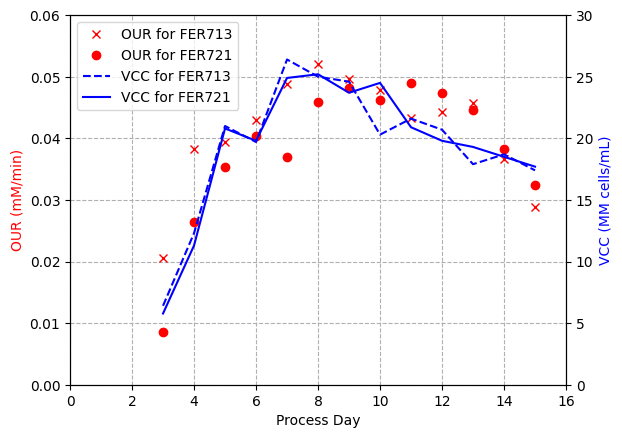

In [79]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
r709 = our_data[our_data["Reactor"]==713]
r717 = our_data[our_data["Reactor"]==721]
# plt.plot(r709['Process Day'], r709['csOUR (pmol/(cell*day)'],"ro-", label="csOUR for FER709")
# plt.plot(r717['Process Day'], r717['csOUR (pmol/(cell*day)'],"bo-", label="csOUR for FER717")
lns1=ax.plot(r709['Process Day'], r709['OUR (mM/min)'],"rx", label="OUR for FER713")
lns2=ax.plot(r717['Process Day'], r717['OUR (mM/min)'],"ro", label="OUR for FER721")
lns3=ax2.plot(r709['Process Day'], r709['Cell Count (MM/mL)'],"b--", label="VCC for FER713")
lns4=ax2.plot(r717['Process Day'], r717['Cell Count (MM/mL)'],"b-", label="VCC for FER721")
plt.xlim(0,16)
ax.set_ylim(0,0.06)
ax2.set_ylim(0,30)
ax.set_xlabel('Process Day')
ax.set_ylabel('OUR (mM/min)', color='r')
ax2.set_ylabel('VCC (MM cells/mL)', color='b')
# added these three lines
lns = lns1+lns2+lns3+lns4
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc=0)
ax.grid(linestyle='--')

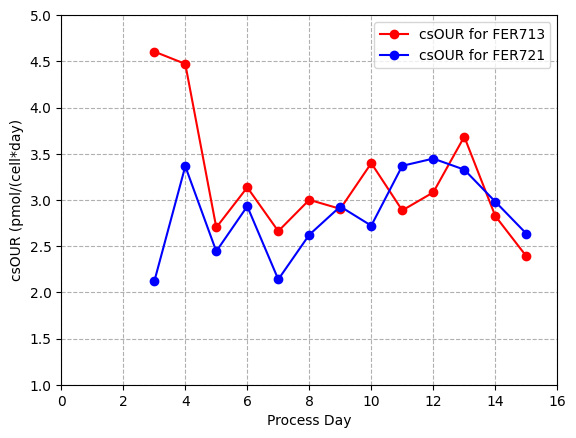

In [80]:
fig, ax = plt.subplots()
r709 = our_data[our_data["Reactor"]==713]
r717 = our_data[our_data["Reactor"]==721]
plt.plot(r709['Process Day'], r709['csOUR (pmol/(cell*day)'],"ro-", label="csOUR for FER713")
plt.plot(r717['Process Day'], r717['csOUR (pmol/(cell*day)'],"bo-", label="csOUR for FER721")
# lns1=ax.plot(r709['Process Day'], r709['OUR (mM/min)'],"rx", label="OUR for FER709")
# lns2=ax.plot(r717['Process Day'], r717['OUR (mM/min)'],"ro", label="OUR for FER717")
# lns3=ax2.plot(r709['Process Day'], r709['Cell Count (MM/mL)'],"b--", label="VCC for FER709")
# lns4=ax2.plot(r717['Process Day'], r717['Cell Count (MM/mL)'],"b-", label="VCC for FER717")
plt.xlim(0,16)
ax.set_ylim(1,5)
ax.set_xlabel('Process Day')
ax.set_ylabel('csOUR (pmol/(cell*day)')
ax.legend()
ax.grid(linestyle='--')

In [53]:
df = pd.read_csv(r'C:\Users\zah48132\OneDrive - GSK\Documents\GitHub\state-space-model\data\raw\AR22-001-Model-Data.csv')
df.head()

,Batch,Condition,Day,Sample Time,TCC,VCC,Lact,Osmo,Gluc,Ammonium,IGG,F30 Feed Amount (mL),Glucose Added (mL),Volume,Daily_Feed_Normalized,Daily_Glucose_Normalized
0,AR22-001-002,CSFR: 0.00023 to 0.00037,0,1/19/2022 13:32,27.5054,27.4820,0.68,332.0,6.96,3.85,100.0,1.15,0.0,179.68,0.006400,0.0
1,AR22-001-003,CSFR: 0.00037 to 0.0004 to 0.00023,0,1/19/2022 13:38,24.3893,24.3867,0.69,333.0,6.93,3.82,100.0,1.65,0.0,180.19,0.009157,0.0
2,AR22-001-004,CSFR: 0.0003,0,1/19/2022 13:44,24.5271,24.5024,0.69,333.0,6.84,3.83,100.0,1.33,0.0,179.86,0.007395,0.0
3,AR22-001-005,CSFR: 0.0001 to 0.0004 to 0.0001,0,1/19/2022 13:50,24.2632,24.2632,0.70,333.0,6.89,3.91,100.0,0.44,0.0,178.98,0.002458,0.0
4,AR22-001-006,CSFR: 0.00023 to 0.0002 to 0.00037,0,1/19/2022 13:55,25.2902,25.2668,0.71,334.0,6.79,3.88,100.0,1.06,0.0,179.60,0.005902,0.0


In [54]:
def clean_data(df):
    df["F30 Feed Amount (mL)"] = np.diff(
        df["F30 Feed Amount (mL)"], n=1, prepend=0
    )
    df["Glucose Added (mL)"] = np.diff(
        df["Glucose Added (mL)"], n=1, prepend=0
    )

    # Make scale dependent variables independent
    df["F30 Feed Amount (mL)"] = df["F30 Feed Amount (mL)"] / df['Volume']
    df["Glucose Added (mL)"] = df["Glucose Added (mL)"] / df['Volume']
    return df

In [55]:
grouped = df.groupby(["Batch"])
new_df = grouped.apply(clean_data)

C:\Users\zah48132\AppData\Local\Temp\ipykernel_35848\331878668.py:2: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  new_df = grouped.apply(clean_data)


In [56]:
new_df[new_df["Day"] > 0].filter(items=["Day","VCC","Lact","Osmo"]).iloc[0]

Day       1.0000
VCC      41.2412
Lact      0.9900
Osmo    290.0000
Name: 21, dtype: float64

In [57]:
new_df

,Batch,Condition,Day,Sample Time,TCC,VCC,Lact,Osmo,Gluc,Ammonium,IGG,F30 Feed Amount (mL),Glucose Added (mL),Volume,Daily_Feed_Normalized,Daily_Glucose_Normalized
0,AR22-001-002,CSFR: 0.00023 to 0.00037,0,1/19/2022 13:32,27.5054,27.4820,0.68,332.0,6.96,3.85,100.000,0.006400,0.0,179.680,0.006400,0.0
1,AR22-001-003,CSFR: 0.00037 to 0.0004 to 0.00023,0,1/19/2022 13:38,24.3893,24.3867,0.69,333.0,6.93,3.82,100.000,0.009157,0.0,180.190,0.009157,0.0
2,AR22-001-004,CSFR: 0.0003,0,1/19/2022 13:44,24.5271,24.5024,0.69,333.0,6.84,3.83,100.000,0.007395,0.0,179.860,0.007395,0.0
3,AR22-001-005,CSFR: 0.0001 to 0.0004 to 0.0001,0,1/19/2022 13:50,24.2632,24.2632,0.70,333.0,6.89,3.91,100.000,0.002458,0.0,178.980,0.002458,0.0
4,AR22-001-006,CSFR: 0.00023 to 0.0002 to 0.00037,0,1/19/2022 13:55,25.2902,25.2668,0.71,334.0,6.79,3.88,100.000,0.005902,0.0,179.600,0.005902,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,AR22-001-019,CSFR: 0.00037 to 0.0002 to 0.00023,12,1/31/2022 6:50,37.2307,31.8344,0.25,338.0,1.05,12.55,5526.315,0.000000,0.0,199.280,0.000000,0.0
269,AR22-001-016,CSFR: 0.0005,12,1/31/2022 6:26,28.6741,1.9370,8.34,710.0,4.47,30.86,3372.765,0.000000,0.0,231.610,0.000000,0.0
270,AR21-048-009,CSFR: 0.0000 to 0.0007,12,10/25/2021 9:50,30.4000,25.3270,1.42,416.0,2.91,17.56,5562.270,0.000000,0.0,213.330,0.000000,0.0
271,AR21-048-003,CSFR: 0.0000 to 0.00035,12,10/25/2021 9:44,29.3760,27.0760,0.08,288.0,0.45,8.56,5113.710,0.000000,0.0,187.920,0.000000,0.0


In [58]:
DISCARD = [
    "AR21-048-001",
    "AR21-048-003",
    "AR21-048-009",
    "AR22-001-001",
]

feature_minmaxscaling_exclusion = [
    "Batch",
    "Day",
    "Condition",
    "Sample Time",
    "Volume",
]

new_list = DISCARD + feature_minmaxscaling_exclusion
new_list

['AR21-048-001',
 'AR21-048-003',
 'AR21-048-009',
 'AR22-001-001',
 'Batch',
 'Day',
 'Condition',
 'Sample Time',
 'Volume']

In [59]:
df['savgol'] = df.groupby('Batch')['VCC'].transform(lambda x: savgol_filter(x, 3,2))

Batch
AR21-048-003    AxesSubplot(0.125,0.11;0.775x0.77)
AR21-048-009    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-001    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-002    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-003    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-004    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-005    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-006    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-007    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-008    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-009    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-010    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-011    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-012    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-013    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-014    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-015    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-016    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-017    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-018    AxesSubpl

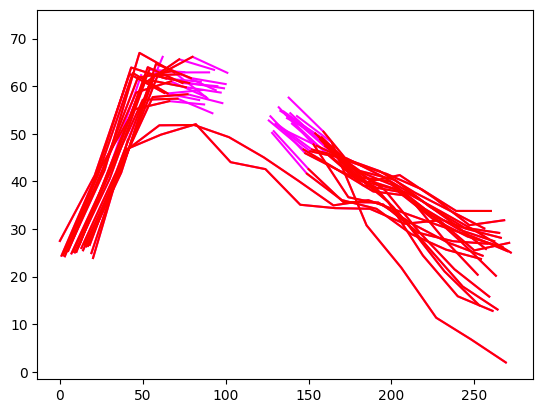

In [60]:
df.groupby('Batch')['VCC'].plot(colormap="spring")
df.groupby('Batch')['savgol'].plot(colormap="autumn")

In [61]:
def grpfunc(grp):

    n = len(grp)
    x = np.arange(n)

    spl = UnivariateSpline(x, grp.values, s=n)

    return spl(x)

df_group = df.groupby("Batch")[["TCC","VCC","Lact","Osmo"]].transform(grpfunc)
df_group

,TCC,VCC,Lact,Osmo
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
268,NaN,NaN,NaN,NaN
269,NaN,NaN,NaN,NaN
270,30.147866,25.490900,1.461813,416.132767
271,29.207970,26.834371,NaN,288.087219


In [62]:
batch_dict = {}
poly_fit = True
x = np.linspace(0,12,13)
for i in df['Batch'].unique():
    df_batch = df[df['Batch']==i]
    df_batch = df_batch[['Day','TCC','VCC','Lact','Gluc','Osmo','Ammonium','IGG','F30 Feed Amount (mL)','Glucose Added (mL)','Volume']]
    df_batch.interpolate(method = 'linear',inplace=True)
    df_batch.interpolate(method = 'backfill', inplace=True,limit_direction='backward',limit=2)
    df_batch['Daily Feed Fed (mL)'] = np.diff(df_batch['F30 Feed Amount (mL)'],n=1,prepend=0)
    df_batch['Daily Glucose Fed (mL)'] = np.diff(df_batch['Glucose Added (mL)'],n=1,prepend=0)
    df_batch['CSFR'] = (df_batch['Daily Feed Fed (mL)']/(24*60))/(df_batch['VCC']*.18)
    spl_tcc = UnivariateSpline(x,df_batch['TCC'])
    spl_vcc = UnivariateSpline(x,df_batch['VCC'])
    spl_lact = UnivariateSpline(x,df_batch['Lact'])
    spl_osmo = UnivariateSpline(x,df_batch['Osmo'])
    spl_amm = UnivariateSpline(x,df_batch['Ammonium'])
    spl_igg = UnivariateSpline(x,df_batch['IGG'])
    #spl_gluc = UnivariateSpline(x,df_batch['Gluc'])
    #spl_feed = UnivariateSpline(x,df_batch['F30 Feed Amount (mL)'])
    if poly_fit == True:
        df_batch['TCC'] = spl_tcc(x)
        df_batch['VCC'] = spl_vcc(x)
        df_batch['Lact'] = spl_lact(x)
        #df_batch['Gluc'] = spl_gluc(x)
        df_batch['Osmo'] = spl_osmo(x)
        df_batch['Ammonium'] = spl_amm(x)
        df_batch['IGG'] = spl_igg(x)
        #df_batch['F30 Feed Amount (mL)'] = spl_feed(x)
    else:
        pass
    df_batch = df_batch.replace(np.nan,0)
    batch_dict[i] = df_batch
interpolated_df = pd.concat(batch_dict)

In [63]:
list1 = ["VCC", "TCC"]
df[set(df.columns) - set(list1)]

C:\Users\zah48132\AppData\Local\Temp\ipykernel_35848\3855193560.py:2: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  df[set(df.columns) - set(list1)]


,Sample Time,Lact,Daily_Feed_Normalized,Batch,savgol,Day,Condition,IGG,F30 Feed Amount (mL),Glucose Added (mL),Volume,Osmo,Gluc,Ammonium,Daily_Glucose_Normalized
0,1/19/2022 13:32,0.68,0.006400,AR22-001-002,27.4820,0,CSFR: 0.00023 to 0.00037,100.000,1.15,0.00,179.680,332.0,6.96,3.85,0.0
1,1/19/2022 13:38,0.69,0.009157,AR22-001-003,24.3867,0,CSFR: 0.00037 to 0.0004 to 0.00023,100.000,1.65,0.00,180.190,333.0,6.93,3.82,0.0
2,1/19/2022 13:44,0.69,0.007395,AR22-001-004,24.5024,0,CSFR: 0.0003,100.000,1.33,0.00,179.860,333.0,6.84,3.83,0.0
3,1/19/2022 13:50,0.70,0.002458,AR22-001-005,24.2632,0,CSFR: 0.0001 to 0.0004 to 0.0001,100.000,0.44,0.00,178.980,333.0,6.89,3.91,0.0
4,1/19/2022 13:55,0.71,0.005902,AR22-001-006,25.2668,0,CSFR: 0.00023 to 0.0002 to 0.00037,100.000,1.06,0.00,179.600,334.0,6.79,3.88,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,1/31/2022 6:50,0.25,0.000000,AR22-001-019,31.8344,12,CSFR: 0.00037 to 0.0002 to 0.00023,5526.315,31.33,13.90,199.280,338.0,1.05,12.55,0.0
269,1/31/2022 6:26,8.34,0.000000,AR22-001-016,1.9370,12,CSFR: 0.0005,3372.765,62.56,7.80,231.610,710.0,4.47,30.86,0.0
270,10/25/2021 9:50,1.42,0.000000,AR21-048-009,25.3270,12,CSFR: 0.0000 to 0.0007,5562.270,38.60,16.79,213.330,416.0,2.91,17.56,0.0
271,10/25/2021 9:44,0.08,0.000000,AR21-048-003,27.0760,12,CSFR: 0.0000 to 0.00035,5113.710,17.30,13.29,187.920,288.0,0.45,8.56,0.0


In [64]:
df.groupby("Batch").size()

Batch
AR21-048-003    13
AR21-048-009    13
AR22-001-001    13
AR22-001-002    13
AR22-001-003    13
AR22-001-004    13
AR22-001-005    13
AR22-001-006    13
AR22-001-007    13
AR22-001-008    13
AR22-001-009    13
AR22-001-010    13
AR22-001-011    13
AR22-001-012    13
AR22-001-013    13
AR22-001-014    13
AR22-001-015    13
AR22-001-016    13
AR22-001-017    13
AR22-001-018    13
AR22-001-019    13
dtype: int64

In [65]:
import pandas as pd

In [66]:
import random
random.randint(-2,2)

0

In [67]:
import numpy as np
test = np.arange(0,15)
test[-1]

14

In [68]:
list_val = []
for day in range(0,14):
    value = np.polyval([2.245,-43.806,216.7205,-72.4427],day)
    list_val.append(value)

In [69]:
list_val[4]

237.22330000000005

In [70]:
df_test = pd.read_csv(r"~\GSK\Biopharm Model Predictive Control - General\data\AR23-014_029-Model-Data.csv")
df_test.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\zah48132\\GSK\\Biopharm Model Predictive Control - General\\data\\AR23-014_029-Model-Data.csv'

In [ ]:
grouped = df.groupby("Batch", group_keys=False)
grouped.apply(lambda group: group.interpolate(method = 'linear'))
grouped.apply(lambda group: group.interpolate(method = 'backfill', limit_direction='backward',limit=2))

,Batch,Condition,Day,Sample Time,TCC,VCC,Lact,Osmo,Gluc,Ammonium,IGG,F30 Feed Amount (mL),Glucose Added (mL),Volume
0,AR22-001-002,CSFR: 0.00023 to 0.00037,0,1/19/2022 13:32,27.5054,27.4820,0.68,332.0,6.96,3.85,100.000,1.15,0.00,179.680
1,AR22-001-003,CSFR: 0.00037 to 0.0004 to 0.00023,0,1/19/2022 13:38,24.3893,24.3867,0.69,333.0,6.93,3.82,100.000,1.65,0.00,180.190
2,AR22-001-004,CSFR: 0.0003,0,1/19/2022 13:44,24.5271,24.5024,0.69,333.0,6.84,3.83,100.000,1.33,0.00,179.860
3,AR22-001-005,CSFR: 0.0001 to 0.0004 to 0.0001,0,1/19/2022 13:50,24.2632,24.2632,0.70,333.0,6.89,3.91,100.000,0.44,0.00,178.980
4,AR22-001-006,CSFR: 0.00023 to 0.0002 to 0.00037,0,1/19/2022 13:55,25.2902,25.2668,0.71,334.0,6.79,3.88,100.000,1.06,0.00,179.600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,AR22-001-019,CSFR: 0.00037 to 0.0002 to 0.00023,12,1/31/2022 6:50,37.2307,31.8344,0.25,338.0,1.05,12.55,5526.315,31.33,13.90,199.280
269,AR22-001-016,CSFR: 0.0005,12,1/31/2022 6:26,28.6741,1.9370,8.34,710.0,4.47,30.86,3372.765,62.56,7.80,231.610
270,AR21-048-009,CSFR: 0.0000 to 0.0007,12,10/25/2021 9:50,30.4000,25.3270,1.42,416.0,2.91,17.56,5562.270,38.60,16.79,213.330
271,AR21-048-003,CSFR: 0.0000 to 0.00035,12,10/25/2021 9:44,29.3760,27.0760,0.08,288.0,0.45,8.56,5113.710,17.30,13.29,187.920


Batch
AR21-048-003    AxesSubplot(0.125,0.11;0.775x0.77)
AR21-048-009    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-001    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-002    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-003    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-004    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-005    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-006    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-007    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-008    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-009    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-010    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-011    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-012    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-013    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-014    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-015    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-016    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-017    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-018    AxesSubpl

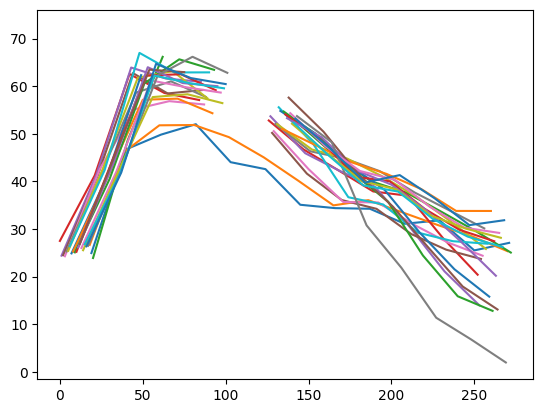

In [ ]:
df.groupby('Batch')['VCC'].plot()

In [20]:
mpc_data = pd.read_clipboard()
mpc_data.head()

,Condition,Day,Titer,Feed Amount
0,SS Model Feeding Strategy,0,36.309524,4.500000
1,SS Model Feeding Strategy,1,206.407594,4.635000
2,SS Model Feeding Strategy,2,446.142568,4.774050
3,SS Model Feeding Strategy,3,754.505778,4.917272
4,SS Model Feeding Strategy,4,1122.532837,5.064790


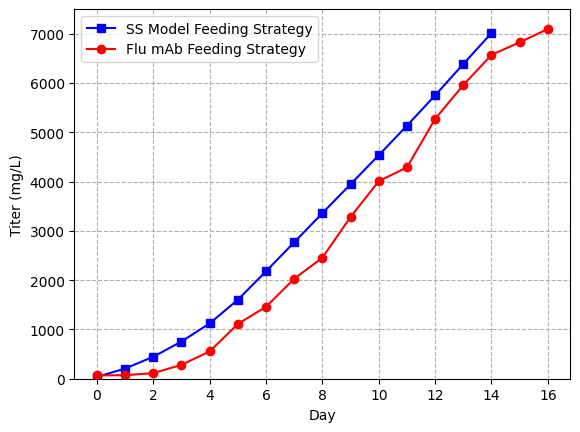

In [16]:
fig, ax = plt.subplots()
mpc = mpc_data[mpc_data["Condition"]=="SS Model Feeding Strategy"]
flu_mab = mpc_data[mpc_data["Condition"]=="Flu mAb Feeding Strategy"]
# plt.plot(r709['Process Day'], r709['csOUR (pmol/(cell*day)'],"ro-", label="csOUR for FER709")
# plt.plot(r717['Process Day'], r717['csOUR (pmol/(cell*day)'],"bo-", label="csOUR for FER717")
lns1=ax.plot(mpc['Day'], mpc['Titer'],"b-s", label="SS Model Feeding Strategy")
lns2=ax.plot(flu_mab['Day'], flu_mab['Titer'],"r-o", label="Flu mAb Feeding Strategy")

ax.set_ylim(0,7500)
ax.set_xlabel('Day')
ax.set_ylabel('Titer (mg/L)')

# added these three lines
# lns = lns1+lns2+lns3+lns4
# labs = [l.get_label() for l in lns]
ax.legend()
ax.grid(linestyle='--')

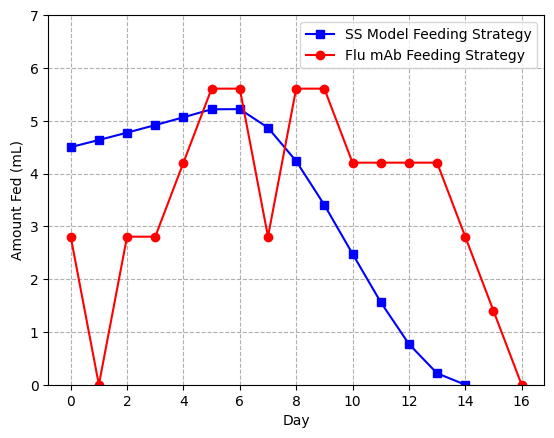

In [21]:
fig, ax = plt.subplots()
mpc = mpc_data[mpc_data["Condition"]=="SS Model Feeding Strategy"]
flu_mab = mpc_data[mpc_data["Condition"]=="Flu mAb Feeding Strategy"]
# plt.plot(r709['Process Day'], r709['csOUR (pmol/(cell*day)'],"ro-", label="csOUR for FER709")
# plt.plot(r717['Process Day'], r717['csOUR (pmol/(cell*day)'],"bo-", label="csOUR for FER717")
lns1=ax.plot(mpc['Day'], mpc['Feed Amount'],"b-s", label="SS Model Feeding Strategy")
lns2=ax.plot(flu_mab['Day'], flu_mab['Feed Amount'],"r-o", label="Flu mAb Feeding Strategy")

ax.set_ylim(0,7)
ax.set_xlabel('Day')
ax.set_ylabel('Amount Fed (mL)')

# added these three lines
# lns = lns1+lns2+lns3+lns4
# labs = [l.get_label() for l in lns]
ax.legend()
ax.grid(linestyle='--')